# Get yo packages baybee

In [8]:
import numpy as np
import pandas as pd
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
import ruptures as rpt
from pipeline import *

# Load yo data

In [9]:

binance = Binance().data

df = Reddit().data
df['datetime'] = pd.to_datetime(df['utc'], unit='s')

df = df.sort_values('datetime')

df['hour'] = df['datetime'].dt.floor('h')
mod_list = ['42points', 'Jools1802', 'GoodShibe', 'jimjunkdude', 'FloodgatesBot', 'RepostSleuthBot', 'AutoModerator']

df["is_moderator"] = df["from"].isin(mod_list)

df["to_moderator"] = df["to"].isin(mod_list)

df[df['is_moderator'] == 1]['from'].value_counts()

df.head()


,from,to,time,utc,post.id,comment.id,parent.id,from_moderator,to_moderator,datetime,hour,is_moderator
0,Professional_Feed478,Professional_Feed478,2020-12-01 02:05:52,1606784752,k4a18g,k4a18g,k4a18g,False,False,2020-12-01 01:05:52,2020-12-01 01:00:00,False
1,Sporklin,Professional_Feed478,2020-12-01 02:24:55,1606785895,k4a18g,ge7onzo,t3_k4a18g,False,False,2020-12-01 01:24:55,2020-12-01 01:00:00,False
2,shibe5,Professional_Feed478,2020-12-01 02:44:12,1606787052,k4a18g,ge7qspw,t3_k4a18g,False,False,2020-12-01 01:44:12,2020-12-01 01:00:00,False
3,HubertHamster,HubertHamster,2020-12-01 03:19:57,1606789197,k4bdlt,k4bdlt,k4bdlt,False,False,2020-12-01 02:19:57,2020-12-01 02:00:00,False
4,AutoModerator,HubertHamster,2020-12-01 03:19:58,1606789198,k4bdlt,ge7usya,t3_k4bdlt,True,False,2020-12-01 02:19:58,2020-12-01 02:00:00,True


# Load yo network and centrality measures

In [10]:

with open('graph.pkl', 'rb') as f:
    G = pickle.load(f)

In [11]:

deg_cent = load_pickle('top_degrees.pkl')
bet_cent = load_pickle('top_betweeness.pkl')

# show top users
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

# pytorch yo graph

In [12]:

# PyTorch object with edges and node degree
pyg_graph, node_mapping = networkx_to_pyg(G)
print(f"PyG Graph: {pyg_graph}")

PyG Graph: Data(x=[389931, 1], edge_index=[2, 2306266], num_nodes=389931)


# Define the architechture, COPY OF ROB at the end of the day

In [13]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.optim as optim
from torch_geometric.utils import negative_sampling

# We need the edges to tell the model what a "real" connection looks like
edge_index = pyg_graph.edge_index
class GCN(nn.Module):    # graph convolutional network, each layer aggregates information from neighbors
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # first layer with ReLU activation
        x = self.conv2(x, edge_index) # second layer (output)
        return x

# Create model and optimizer
model = GCN(in_channels=pyg_graph.x.shape[1], # each layer aggregates information from neighbors, so input is node feature dimension (degree)
            hidden_channels=64, 
            out_channels=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()


# REAL SAUCE training pipeline

In [14]:
from torch_geometric.transforms import RandomLinkSplit

# 1. Split data: 80% for training, 20% for testing the 'Link Prediction'
transform = RandomLinkSplit(num_val=0.0, num_test=0.2, is_undirected=True, add_negative_train_samples=False)
train_data, val_data, test_data = transform(pyg_graph)

# 2. Update the training loop to use train_data.edge_label_index
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    
    # Use ONLY the training edges for message passing
    z = model(train_data.x, train_data.edge_index)
    
    # Predict on the 'label' edges (the ones we want to check)
    pos_edge_index = train_data.edge_label_index
    pos_out = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    
    # Negative sampling
    neg_edge_index = negative_sampling(train_data.edge_index, num_nodes=train_data.num_nodes)
    neg_out = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)
    
    # Loss calculation (binary cross entropy with negative sampling)
    # actual nodes if predicted as real nodes with a high score really improve the loss while fake nodes if predicted as real nodes really messes up the loss
    # Prevents cheating baybee
    
    pos_loss = -torch.log(torch.sigmoid(pos_out) + 1e-15).mean()
    neg_loss = -torch.log(1 - torch.sigmoid(neg_out) + 1e-15).mean()
    loss = pos_loss + neg_loss
    
    loss.backward()
    optimizer.step()
# We get a confidence 0,1 output, 1 meaning model predicts its real

# Eval

In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate_link_prediction(data):
    model.eval()
    
    # 1. Get embeddings using the message-passing edges (edge_index)
    z = model(data.x, data.edge_index)
    
    # 2. Get predictions for positive test edges
    pos_edge_index = data.edge_label_index
    pos_out = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    pos_probs = torch.sigmoid(pos_out).cpu().numpy()
    
    # 3. Get predictions for negative test edges
    # (RandomLinkSplit automatically creates these in test_data)
    neg_edge_index = data.edge_label_index.clone() # We'll swap these for negative samples
    # RandomLinkSplit usually provides negative samples in the label_index if configured, 
    # but here we'll use the negative labels provided by the split:
    neg_probs = torch.sigmoid((z[data.edge_label_index[0]] * z[data.edge_label_index[1]]).sum(dim=-1)).cpu().numpy()
    
    # Since RandomLinkSplit stacks positive and negative in edge_label_index:
    # labels are stored in data.edge_label
    y_true = data.edge_label.cpu().numpy()
    y_pred = torch.sigmoid((z[data.edge_label_index[0]] * z[data.edge_label_index[1]]).sum(dim=-1)).detach().cpu().numpy()
    
    auc = roc_auc_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    
    return auc, ap

# Run evaluation on test set
test_auc, test_ap = evaluate_link_prediction(test_data)
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test Average Precision: {test_ap:.4f}")

Test ROC-AUC: 0.8833
Test Average Precision: 0.9252


# Pretty pictures

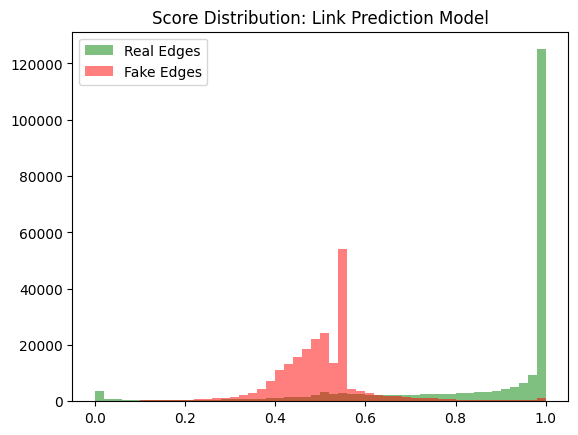

In [16]:
import matplotlib.pyplot as plt

# Get the predictions from the evaluation function
y_true = test_data.edge_label.cpu().numpy()
y_pred = torch.sigmoid((z[test_data.edge_label_index[0]] * z[test_data.edge_label_index[1]]).sum(dim=-1)).detach().cpu().numpy()

plt.hist(y_pred[y_true == 1], bins=50, alpha=0.5, label='Real Edges', color='green')
plt.hist(y_pred[y_true == 0], bins=50, alpha=0.5, label='Fake Edges', color='red')
plt.title("Score Distribution: Link Prediction Model")
plt.legend()
plt.show()

In [17]:
# 1. Get predictions on the test set
z = model(test_data.x, test_data.edge_index)
logits = (z[test_data.edge_label_index[0]] * z[test_data.edge_label_index[1]]).sum(dim=-1)
scores = torch.sigmoid(logits).detach().cpu().numpy()
y_true = test_data.edge_label.detach().cpu().numpy()

# 2. Identify False Positives: Score is high, but Label is 0
threshold = 0.8
fp_mask = (scores > threshold) & (y_true == 0)
fp_indices = test_data.edge_label_index[:, fp_mask]
fp_scores = scores[fp_mask]

# 3. Map back to usernames (reverse node_mapping)
inv_map = {v: k for k, v in node_mapping.items()}

fp_list = []
for i in range(fp_indices.shape[1]):
    u, v = fp_indices[0, i].item(), fp_indices[1, i].item()
    fp_list.append({
        'user_a': inv_map[u],
        'user_b': inv_map[v],
        'score': fp_scores[i]
    })

fp_df = pd.DataFrame(fp_list)
print(f"Found {len(fp_df)} high-confidence False Positives.")

Found 5744 high-confidence False Positives.


In [18]:
# Possible future work
# see if fp_df comes true later to further evaluate the gnn

In [25]:
def get_hourly_network_states(df, model, pyg_graph, node_mapping):
    model.eval()
    with torch.no_grad():
        # Get the 'Universal' embeddings from the GNN
        z = model(pyg_graph.x, pyg_graph.edge_index)
    
    hourly_features = []
    # Group Reddit data by hour
    for hour, group in df.groupby('hour'):
        # Get unique users in this hour
        active_users = group['from'].unique()
        node_ids = [node_mapping[user] for user in active_users if user in node_mapping]
        
        if len(node_ids) > 0:
            # Aggregate: We take the MEAN of all active user embeddings
            # This represents the "Average Vibe" of the community at this hour
            window_embedding = z[node_ids].mean(dim=0).cpu().numpy()
            
            hourly_features.append({
                'hour': hour,
                'network_signal': window_embedding
            })
            
    return pd.DataFrame(hourly_features)

# 1. Generate the hourly signals
network_states = get_hourly_network_states(df, model, pyg_graph, node_mapping)

# 2. Calculate absolute Log Returns for Binance (Stationarity is key!)
binance['log_return'] = (np.log(binance['Close'] / binance['Close'].shift(1)))
binance['abs_return'] = binance['log_return'].abs()
binance['hour'] = pd.to_datetime(binance['Date']).dt.floor('h')

# 3. Merge Social and Price
merged = pd.merge(network_states, binance[['hour', 'log_return']], on='hour').dropna()

# 4. Flatten the 32D embedding into individual columns for the model
emb_cols = [f'emb_{i}' for i in range(32)]
emb_df = pd.DataFrame(merged['network_signal'].tolist(), columns=emb_cols, index=merged.index)
final_df = pd.concat([merged[['hour', 'log_return']], emb_df], axis=1).set_index('hour')

# Volatility

In [27]:
# 1. Create the Volatility Target
final_df['abs_return'] = final_df['log_return'].abs()

results = []
for i in range(32):
    col = f'emb_{i}'
    
    # We test if the Social Embedding (Col) Granger-causes Absolute Returns
    # Note: the target variable must be the FIRST column in the test
    try:
        gc_res = grangercausalitytests(final_df[['abs_return', col]], maxlag=1, verbose=False)
        p_val = gc_res[1][0]['ssr_chi2test'][1]
        results.append((col, p_val))
    except Exception as e:
        # Occasionally a dimension might have 0 variance, skip those
        continue

# 2. Sort by best p-value (lowest is best)
sorted_results = sorted(results, key=lambda x: x[1])

print("--- Volatility Prediction Results ---")
for dim, p in sorted_results[:5]:
    status = "SIGNIFICANT" if p < 0.05 else "Insignificant"
    print(f"{dim}: p-value = {p:.4f} ({status})")

--- Volatility Prediction Results ---
emb_24: p-value = 0.0000 (SIGNIFICANT)
emb_27: p-value = 0.0000 (SIGNIFICANT)
emb_7: p-value = 0.0000 (SIGNIFICANT)
emb_19: p-value = 0.0000 (SIGNIFICANT)
emb_21: p-value = 0.0000 (SIGNIFICANT)


In [35]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Feature Engineering: Add Lagged Volatility
# Finance Rule: The best predictor of future volatility is current volatility.
final_df['lagged_vol'] = final_df['abs_return'] 
final_df['target_vol'] = final_df['abs_return'].shift(-1)

# 2. Log-Transform the target to handle 'Meme-coin' spikes
# This makes the distribution more Gaussian and easier for Ridge to learn.
final_df['target_vol_log'] = np.log(final_df['target_vol'] + 1e-9)

# Clean up NaNs from shifting
data = final_df.dropna()

# 3. Define Features (32 GNN Dims + 1 Price Feature)
emb_cols = [f'emb_{i}' for i in range(32)]
features = emb_cols + ['lagged_vol']

X = data[features]
y = data['target_vol_log']

# 4. Temporal Split (80/20) - No shuffling for time-series!
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 5. Scaling: Bring GNN vectors and Price into the same universe
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train Ridge Regression
# Alpha=10 provides strong regularization to ignore the 'noise' in Reddit data
model_final = Ridge(alpha=10.0)
model_final.fit(X_train_scaled, y_train)
# 7. Evaluate
y_pred_log = model_final.predict(X_test_scaled)

# Fix: Only pass true and predicted values to r2_score
r2 = r2_score(y_test, y_pred_log)

# Convert back from Log-space to real Volatility for your Thesis plots
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

print(f"--- Final Regression Results ---")
print(f"Volatility Prediction R^2: {r2:.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_real, y_pred_real):.6f}")

--- Final Regression Results ---
Volatility Prediction R^2: 0.0137
Mean Absolute Error: 0.006902


--- Directional Regression Results (The 'Failure' Test) ---
Log Return Prediction R^2: -0.0075
Mean Absolute Error: 0.010168


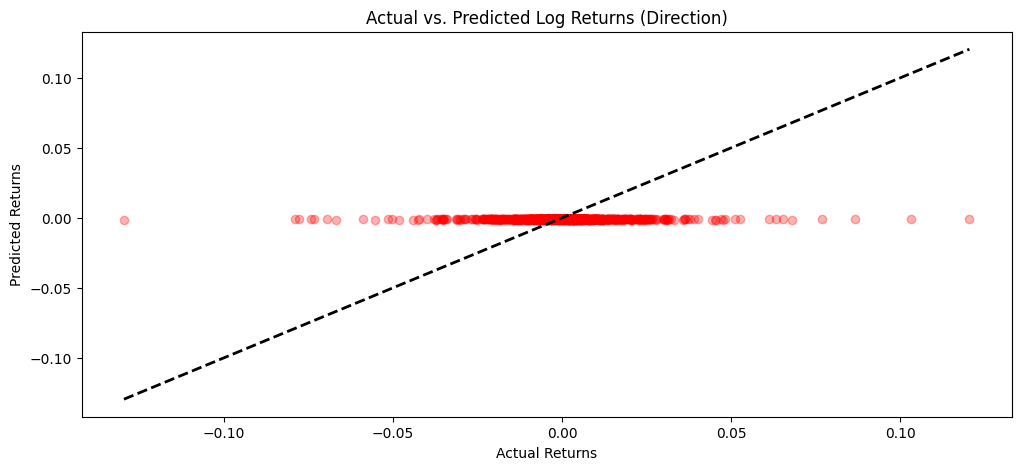

In [37]:
# 1. Prepare the T+1 Target for Directional Price Change
# We are trying to see if the social state at Time T predicts the gain/loss at T+1
final_df['target_return'] = final_df['log_return'].shift(-1)
data_dir = final_df.dropna()

# 2. Define Features
emb_cols = [f'emb_{i}' for i in range(32)]
X_dir = data_dir[emb_cols] # We use ONLY the social embeddings here
y_dir = data_dir['target_return']

# 3. Temporal Split
split = int(len(data_dir) * 0.8)
X_train_dir, X_test_dir = X_dir.iloc[:split], X_dir.iloc[split:]
y_train_dir, y_test_dir = y_dir.iloc[:split], y_dir.iloc[split:]

# 4. Standardize
scaler_dir = StandardScaler()
X_train_scaled_dir = scaler_dir.fit_transform(X_train_dir)
X_test_scaled_dir = scaler_dir.transform(X_test_dir)

# 5. Train Ridge Regression
model_dir = Ridge(alpha=10.0)
model_dir.fit(X_train_scaled_dir, y_train_dir)

# 6. Evaluate
y_pred_dir = model_dir.predict(X_test_scaled_dir)
r2_dir = r2_score(y_test_dir, y_pred_dir)
mae_dir = mean_absolute_error(y_test_dir, y_pred_dir)

print(f"--- Directional Regression Results (The 'Failure' Test) ---")
print(f"Log Return Prediction R^2: {r2_dir:.4f}")
print(f"Mean Absolute Error: {mae_dir:.6f}")

# 7. Visualization of the Failure
plt.figure(figsize=(12, 5))
plt.scatter(y_test_dir, y_pred_dir, alpha=0.3, color='red')
plt.plot([y_test_dir.min(), y_test_dir.max()], [y_test_dir.min(), y_test_dir.max()], 'k--', lw=2)
plt.title("Actual vs. Predicted Log Returns (Direction)")
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.show()

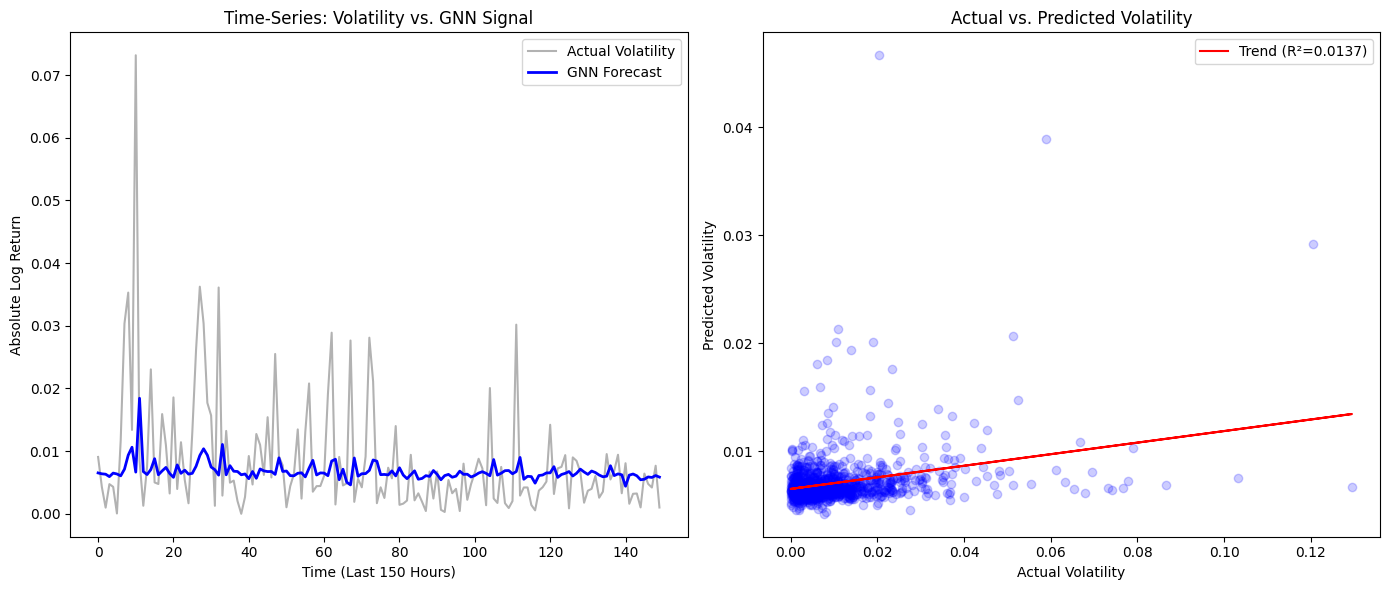

In [38]:
# --- THE "SUCCESS" TEST: PREDICTING MAGNITUDE (VOLATILITY) ---

# 1. Use the predictions from your successful Volatility model (y_test_real vs y_pred_real)
# If you haven't run the Volatility block recently, ensure model_final is trained.

plt.figure(figsize=(14, 6))

# Subplot 1: Time Series Overlay (The 'Tracking' View)
# We look at the last 150 hours to see if the GNN 'echoes' the price swings
plt.subplot(1, 2, 1)
plt.plot(y_test_real.values[-150:], label='Actual Volatility', color='black', alpha=0.3)
plt.plot(y_pred_real[-150:], label='GNN Forecast', color='blue', linewidth=2)
plt.title("Time-Series: Volatility vs. GNN Signal")
plt.xlabel("Time (Last 150 Hours)")
plt.ylabel("Absolute Log Return")
plt.legend()

# Subplot 2: Scatter Plot (The 'Correlation' View)
# This is the direct comparison to your 'Directional' failure plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_real, y_pred_real, alpha=0.2, color='blue')

# Add a trend line to show the positive correlation
m, b = np.polyfit(y_test_real, y_pred_real, 1)
plt.plot(y_test_real, m*y_test_real + b, color='red', label=f'Trend (R²={r2:.4f})')

plt.title("Actual vs. Predicted Volatility")
plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.legend()

plt.tight_layout()
plt.show()